## Lagrange orbits with second order system and hard constains for ICs - Modified RAR training

---



*  In the previous experiments involving the Lagrange periodic orbit, training with only 64 collocation points resulted in limited accuracy and signs of overfitting. Furthermore, satisfactory convergence was difficult to achieve using first-order optimization methods alone, often requiring the use of second-order optimization algorithms such as L-BFGS. However, even with L-BFGS, the overfitting behavior was not eliminated. To address these issues, the Residual-Based Adaptive Refinement (RAR) algorithm was employed. By iteratively introducing additional collocation points in regions where the PDE residual is large, RAR aims to improve the accuracy and generalization capability of the PINN while reducing the need for excessively long training procedures.
  
*   A modified version of the standard Residual-Based Adaptive Refinement (RAR) algorithm was employed in this work. Instead of selecting only the collocation points associated with the largest residual values, new training points were sampled from the subset whose residuals lie between 60% and 95% of the maximum residual. This strategy avoids concentrating refinement exclusively on a small number of extreme-error regions and promotes a more balanced distribution of collocation points throughout the domain. Empirically, this approach yielded better performance than the standard RAR procedure for the problems considered in this study.




In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

## Training

---



Set the default float type to float64
Compiling model...
'compile' took 0.008739 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.42e+01, 3.02e+00, 1.12e+01, 1.45e+01, 5.85e+00, 2.29e+01]    [2.46e+01, 2.17e+00, 9.55e+00, 1.55e+01, 6.33e+00, 2.21e+01]    []  
30000     [4.48e-02, 9.23e-02, 5.96e-02, 9.59e-02, 1.19e-01, 3.53e-02]    [4.08e-02, 1.18e-01, 8.27e-02, 1.03e-01, 1.39e-01, 3.76e-02]    []  

Best model at step 30000:
  train loss: 4.46e-01
  test loss: 5.21e-01
  test metric: []

'train' took 53.664218 s


Starting RAR refinement...


RAR iteration 1/21


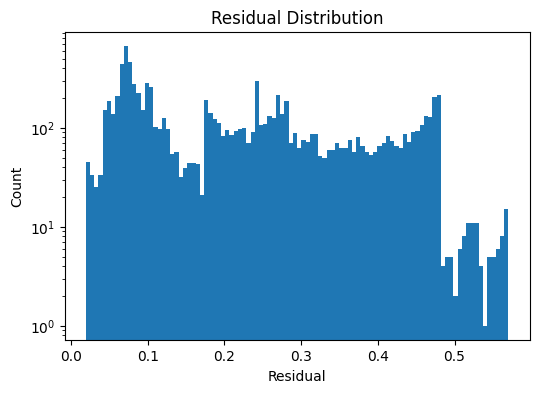

Maximum residual : 5.703e-01
Minimum selected : 2.527e-01
Maximum selected : 4.679e-01
Compiling model...
'compile' took 0.009189 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
30000     [5.32e-02, 1.61e-01, 1.18e-01, 1.39e-01, 1.81e-01, 4.79e-02]    [4.08e-02, 1.18e-01, 8.27e-02, 1.03e-01, 1.39e-01, 3.76e-02]    []  
40000     [2.07e-02, 1.17e-01, 9.00e-02, 5.54e-02, 1.06e-01, 4.26e-02]    [2.45e-02, 1.03e-01, 9.31e-02, 4.79e-02, 9.89e-02, 5.90e-02]    []  

Best model at step 40000:
  train loss: 4.32e-01
  test loss: 4.26e-01
  test metric: []

'train' took 25.945503 s


RAR iteration 2/21
Maximum residual : 6.556e-01
Minimum selected : 2.419e-01
Maximum selected : 3.603e-01
Compiling model...
'compile' took 0.007827 s

Training model...

Step      Train loss                                                      Test loss                                        

Step      Train loss                                                      Test loss                                                       Test metric
60000     [2.73e-02, 5.82e-02, 4.16e-02, 4.68e-02, 5.99e-02, 3.00e-02]    [3.56e-02, 4.91e-02, 6.32e-02, 3.28e-02, 4.99e-02, 4.81e-02]    []  
70000     [2.25e-02, 5.17e-02, 3.68e-02, 3.85e-02, 5.15e-02, 2.57e-02]    [3.70e-02, 4.43e-02, 5.95e-02, 2.82e-02, 4.11e-02, 3.67e-02]    []  

Best model at step 70000:
  train loss: 2.27e-01
  test loss: 2.47e-01
  test metric: []

'train' took 52.411790 s


RAR iteration 5/21


Maximum residual : 5.479e-01
Minimum selected : 1.626e-01
Maximum selected : 2.849e-01
Compiling model...
'compile' took 0.007178 s

Training model...



Step      Train loss                                                      Test loss                                                       Test metric
70000     [2.83e-02, 5.02e-02, 3.90e-02, 4.08e-02, 5.11e-02, 2.70e-02]    [3.70e-02, 4.43e-02, 5.95e-02, 2.82e-02, 4.11e-02, 3.67e-02]    []  
80000     [2.37e-02, 4.57e-02, 3.53e-02, 3.54e-02, 4.47e-02, 2.54e-02]    [3.17e-02, 4.06e-02, 5.83e-02, 2.56e-02, 3.47e-02, 3.26e-02]    []  

Best model at step 80000:
  train loss: 2.10e-01
  test loss: 2.24e-01
  test metric: []

'train' took 56.084865 s


RAR iteration 6/21


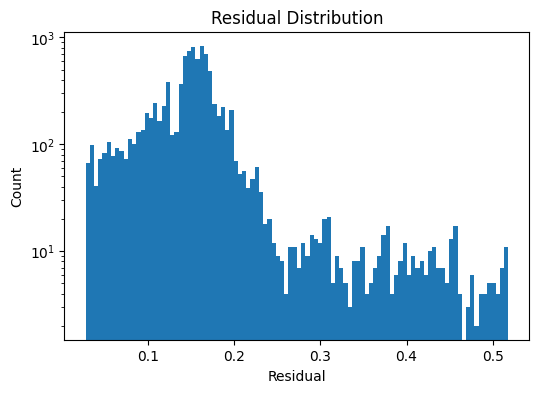

Maximum residual : 5.183e-01
Minimum selected : 1.589e-01
Maximum selected : 2.315e-01
Compiling model...
'compile' took 0.008191 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
80000     [2.67e-02, 4.41e-02, 3.84e-02, 3.71e-02, 4.40e-02, 2.67e-02]    [3.17e-02, 4.06e-02, 5.83e-02, 2.56e-02, 3.47e-02, 3.26e-02]    []  
90000     [2.23e-02, 4.17e-02, 3.36e-02, 3.33e-02, 4.02e-02, 2.43e-02]    [2.72e-02, 3.87e-02, 4.91e-02, 2.26e-02, 3.18e-02, 2.84e-02]    []  

Best model at step 90000:
  train loss: 1.95e-01
  test loss: 1.98e-01
  test metric: []

'train' took 63.342876 s


RAR iteration 7/21
Maximum residual : 5.145e-01
Minimum selected : 1.532e-01
Maximum selected : 1.998e-01
Compiling model...
'compile' took 0.007752 s

Training model...

Step      Train loss                                                      Test loss                                        

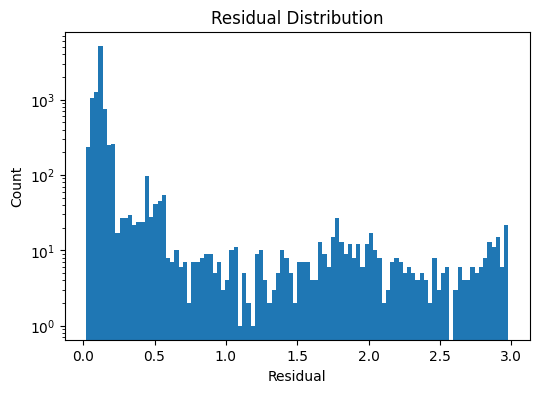

Maximum residual : 2.980e+00
Minimum selected : 1.243e-01
Maximum selected : 8.864e-01
Compiling model...
'compile' took 0.008393 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
130000    [2.39e-01, 1.73e-01, 2.22e-01, 1.86e-01, 1.47e-01, 2.62e-01]    [3.21e-01, 2.42e-01, 3.07e-01, 2.56e-01, 2.04e-01, 3.50e-01]    []  
140000    [1.19e-02, 2.44e-02, 2.29e-02, 1.22e-02, 1.71e-02, 1.67e-02]    [1.58e-02, 2.21e-02, 2.90e-02, 1.20e-02, 1.62e-02, 1.59e-02]    []  

Best model at step 140000:
  train loss: 1.05e-01
  test loss: 1.11e-01
  test metric: []

'train' took 97.095069 s


RAR iteration 12/21
Maximum residual : 5.338e-01
Minimum selected : 1.120e-01
Maximum selected : 1.692e-01
Compiling model...
'compile' took 0.007458 s

Training model...

Step      Train loss                                                      Test loss                                      

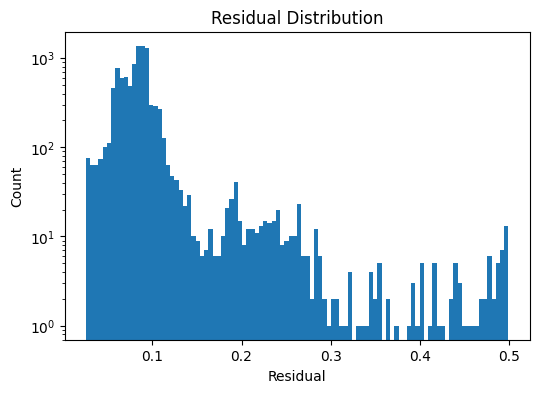

Maximum residual : 4.994e-01
Minimum selected : 8.796e-02
Maximum selected : 1.413e-01
Compiling model...
'compile' took 0.008388 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
180000    [9.02e-03, 1.57e-02, 1.36e-02, 8.35e-03, 1.09e-02, 1.31e-02]    [1.11e-02, 1.36e-02, 1.51e-02, 9.63e-03, 1.15e-02, 1.03e-02]    []  
190000    [8.18e-03, 1.46e-02, 1.28e-02, 7.61e-03, 9.97e-03, 1.24e-02]    [1.02e-02, 1.23e-02, 1.32e-02, 9.14e-03, 1.05e-02, 9.79e-03]    []  

Best model at step 190000:
  train loss: 6.55e-02
  test loss: 6.51e-02
  test metric: []

'train' took 120.226635 s


RAR iteration 17/21
Maximum residual : 4.672e-01
Minimum selected : 8.413e-02
Maximum selected : 1.261e-01
Compiling model...
'compile' took 0.007451 s

Training model...

Step      Train loss                                                      Test loss                                     

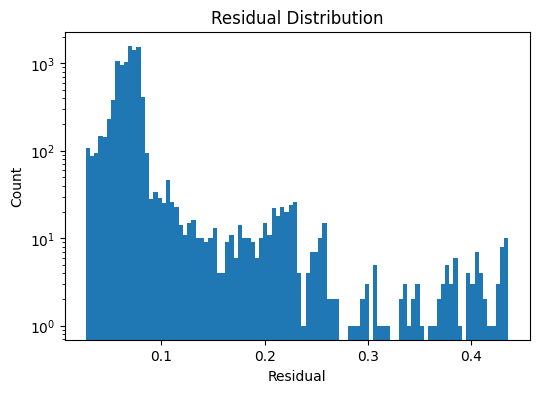

Maximum residual : 4.362e-01
Minimum selected : 7.221e-02
Maximum selected : 1.169e-01
Compiling model...
'compile' took 0.008266 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
230000    [6.06e-03, 1.05e-02, 8.96e-03, 5.99e-03, 7.73e-03, 9.83e-03]    [7.59e-03, 9.93e-03, 9.07e-03, 7.86e-03, 9.07e-03, 8.30e-03]    []  
240000    [5.55e-03, 9.69e-03, 8.36e-03, 5.56e-03, 7.16e-03, 9.33e-03]    [6.97e-03, 9.59e-03, 8.48e-03, 7.39e-03, 8.59e-03, 8.16e-03]    []  

Best model at step 240000:
  train loss: 4.57e-02
  test loss: 4.92e-02
  test metric: []

'train' took 142.072511 s

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


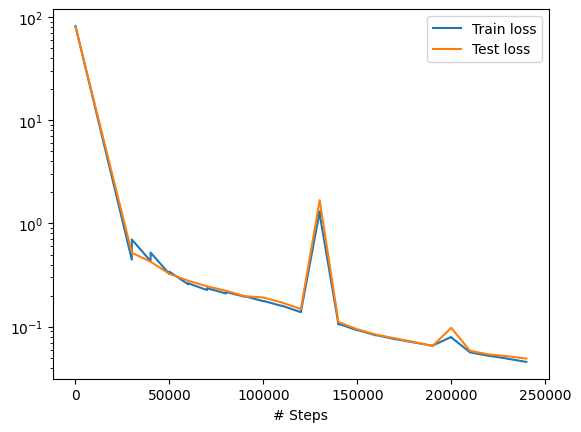

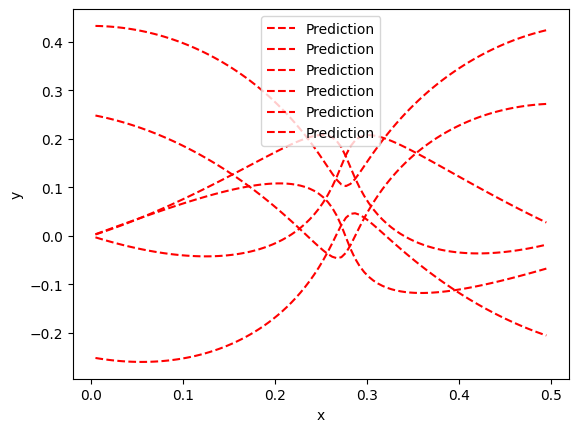

In [ ]:

dde.config.set_default_float("float64")
seed=137

np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# Constants
scale=2  #scale factor  -- time/scale**3 -- space/scale**2 -- velocities*scale
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 4/scale**3

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*3 + [6]  # 6 outputs for positions only
activation = "tanh" #"sin"
initializer = "Glorot uniform" # "He normal" #"Glorot uniform"
loss_weights = [1]*6
iterations = 30000
learning_rate = 1e-4
eps = 1e-9        #softening to avoid division by zero

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
omega=0.3
# positions
x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

# velocities
vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0*scale

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    r12_3 = (r12)**3
    r13_3 = (r13)**3
    r23_3 = (r23)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

model = dde.Model(data, net)



model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
#change display_every=1000 to output progress every 1000 epochs
losshistory, train_state = model.train(iterations=iterations,display_every=300000)


# ============================================================
# RAR LOOP (Residual-based Adaptive Refinement)
# ============================================================

print("\nStarting RAR refinement...\n")

rar_iterations = 21
candidate_points = 10000
points_to_add = 64
# Sample random time points
X = geom.random_points(candidate_points)   # (N,1)
for i in range(rar_iterations):

    print(f"\nRAR iteration {i+1}/{rar_iterations}")

    # Compute residual
    f = model.predict(X, operator=three_body_ode_second)


    # If operator returns list, stack it
    if isinstance(f, list):
      f = np.hstack(f)   # shape becomes (N, 6)
    # Ensure residual is 1D
    residual = np.mean(np.abs(f), axis=1)#.flatten()

    if i%5==0:
      plt.figure(figsize=(6,4))
      plt.hist(residual, bins=100)
      plt.title("Residual Distribution")
      plt.xlabel("Residual")
      plt.ylabel("Count")
      plt.yscale("log")  # important!
      plt.show()


    ###### take the 60%-95% of worst points -- not the worst!
    threshold_low  = np.percentile(residual, 60)
    threshold_high = np.percentile(residual, 95)
    mask = (residual >= threshold_low) & (residual <= threshold_high)
    candidates = X[mask]

    if len(candidates) >= points_to_add:
      idx = np.random.choice(len(candidates), points_to_add, replace=False)
      X_new = candidates[idx]

      candidate_residual = residual[mask]
      selected_residual = candidate_residual[idx]

    else:
    # fallback to top-k
      print("=========> fall back...")
      idx = np.argsort(residual)[-points_to_add:]
      X_new = X[idx]

      selected_residual = residual[idx]
    #############################################################

    # Force correct shape (M,1)
    X_new = X_new.reshape(-1, 1)


    print(f"Maximum residual : {residual.max():.3e}")
    print(f"Minimum selected : {selected_residual.min():.3e}")
    print(f"Maximum selected : {selected_residual.max():.3e}")


    # Add anchors
    data.add_anchors(X_new)

    # Retrain
    #model.compile("L-BFGS")  # no learning rate needed
    #losshistory, train_state = model.train()
    model.compile("adam", lr=1e-4, loss_weights=loss_weights, loss="MSE")
    #change display_every=1000 to output progress every 1000 epochs
    model.train(iterations=10000,display_every=300000,disregard_previous_best=True,)

#model.compile("L-BFGS")  # no learning rate needed
#losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)



#Plots-Results

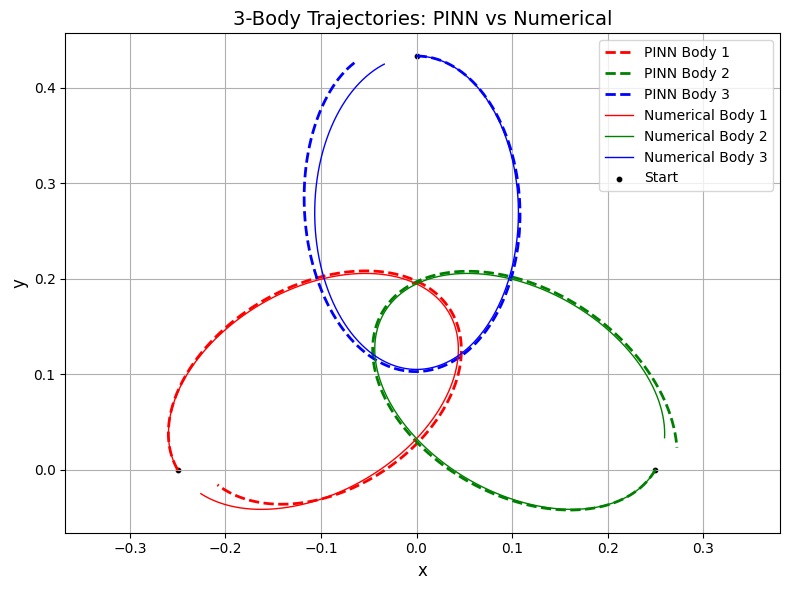


--- L2 Relative Errors ---
Body 1 x error: 5.34e-02
Body 1 y error: 4.87e-02
Body 2 x error: 2.84e-02
Body 2 y error: 3.54e-02
Body 3 x error: 1.58e-01
Body 3 y error: 1.39e-02
(44, 6)


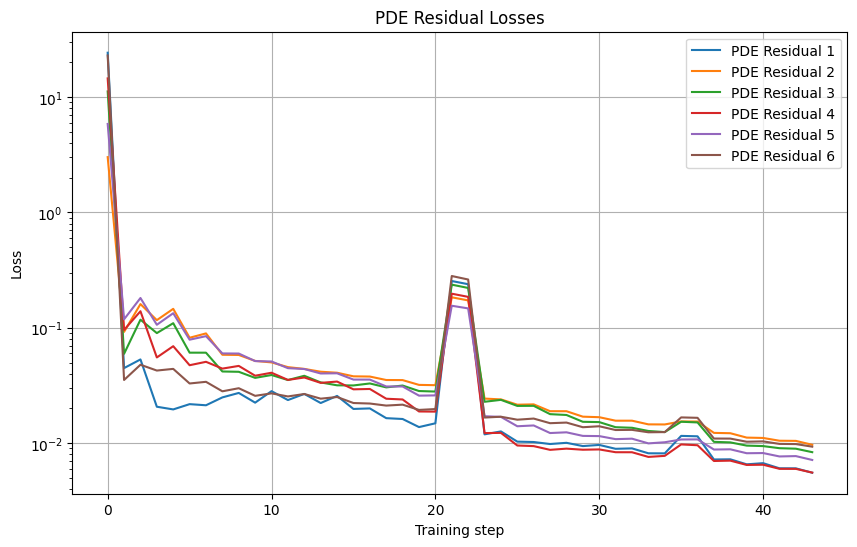

In [ ]:
# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 +eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 +eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 +eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()


#Statistics

In [ ]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

LPDE = final_train_loss     # hard constraints
LDATA = 0.0

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 4.57e-02
Final Test Loss     : 4.92e-02
PDE Residual Loss   : 4.57e-02
Data Loss           : 0.00e+00

Position RMSE
-----------------------------
Body 1 : 1.08e-02
Body 2 : 6.19e-03
Body 3 : 1.33e-02
Global : 1.05e-02

Maximum Position Error
-----------------------------
Body 1 : 1.97e-02
Body 2 : 1.66e-02
Body 3 : 3.09e-02
Global Max Position error : 3.09e-02

Energy Conservation
-----------------------------
PINN ΔE/E0 : 1.89e-02
-----------------------------
Numerical ΔE/E0 : 9.48e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 6.10e-03
-----------------------------
Numerical Max Momentum Drift : 4.93e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 2.73e-02


SUMMARY
Final Training Loss               : 4.57e-02
Final Test Loss                   : 4.92e-02
PDE Residual Loss                 : 4.57e-02
Data Loss                         : 0.00e+00
Global Max Position error         : 3.09e-02
Positi

#Extrapolate

======================= Extrapolating for 2 Periods ===============================


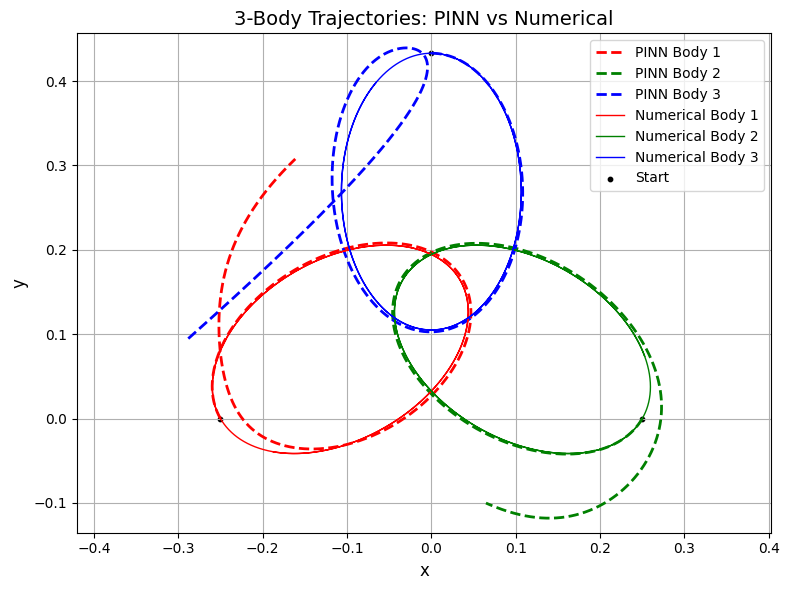


--- L2 Relative Errors ---
Body 1 x error: 4.52e-01
Body 1 y error: 1.13e+00
Body 2 x error: 4.13e-01
Body 2 y error: 1.24e+00
Body 3 x error: 9.15e-01
Body 3 y error: 2.41e-01


In [ ]:

#============================ EXTRAPOLATE =================================================
print("===================================================================================")
print("======================= Extrapolating for 2 Periods ===============================")
print("===================================================================================")

endTime=2*endTime

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")